# Neural Network for CIFAR-10 classification


In this hometask you'll implement and train neural networks for classification of images from the CIFAR-10 dataset.


CIFAR-10 is a dataset of small **color** images from 10 object classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck. Each image has size **32×32×3**. This makes the task harder than MNIST, because now the images are colored and the objects are much more visually diverse.


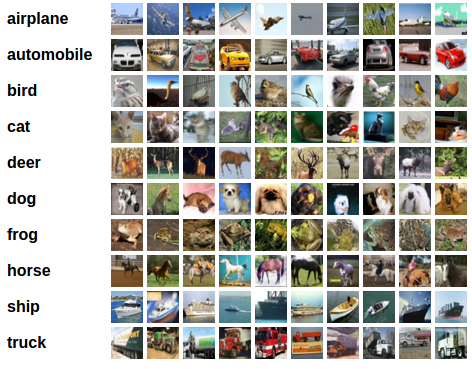

We will also visualize a few CIFAR-10 images after loading the dataset.


## Loading data


The cell below downloads CIFAR-10 using `torchvision`.


In [34]:
import torchvision
from torchvision import transforms

train_dataset_raw = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True
)
test_dataset_raw = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True
)


c:\github_repos\nebius_ai_performance_engineering\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


After this, you'll have the CIFAR-10 training and testing splits downloaded into the `./data` directory.


Let's import NumPy, Pandas and look at our data:


In [35]:
import numpy as np
import pandas as pd

In [36]:
class_names = train_dataset_raw.classes

train_images = train_dataset_raw.data
test_images = test_dataset_raw.data
train_labels = np.array(train_dataset_raw.targets)
test_labels = np.array(test_dataset_raw.targets)

# flatten images so that each object is represented as a vector
train_flat = train_images.reshape(len(train_images), -1)
test_flat = test_images.reshape(len(test_images), -1)

train_data = pd.DataFrame(train_flat)
train_data['label'] = train_labels

test_data = pd.DataFrame(test_flat)
test_data['label'] = test_labels

train_data.head()


,0,1,2,3,4,5,6,7,8,9,...,3063,3064,3065,3066,3067,3068,3069,3070,3071,label
0,59,62,63,43,46,45,50,48,43,68,...,216,184,140,151,118,84,123,92,72,6
1,154,177,187,126,137,136,105,104,95,102,...,143,133,139,143,134,142,143,133,144,9
2,255,255,255,253,253,253,253,253,253,253,...,78,85,83,79,85,83,80,86,84,9
3,28,25,10,37,34,19,38,35,20,42,...,54,47,28,63,56,37,72,65,46,4
4,170,180,198,168,178,196,177,185,203,183,...,75,79,82,71,75,78,73,77,80,1


In this table, each image is represented as a vector of size **32×32×3 = 3072**, where each feature corresponds to one pixel channel (Red, Green or Blue) value. Pixel values are in the range **[0, 255]**.

Column `label` is the target variable representing the image class. The class mapping is:

```python
{idx: name for idx, name in enumerate(class_names)}
```


Let's visualize the first image:


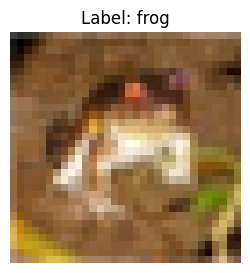

In [37]:
import matplotlib.pyplot as plt

# you can change the index and visualize different images
idx = 0
img = train_images[idx]
plt.figure(figsize=(3, 3))
plt.imshow(img)
plt.title(f'Label: {class_names[train_labels[idx]]}')
plt.axis('off');

Let's also load test data:


In [38]:
# test_data has already been created above
test_data.head()

,0,1,2,3,4,5,6,7,8,9,...,3063,3064,3065,3066,3067,3068,3069,3070,3071,label
0,158,112,49,159,111,47,165,116,51,166,...,24,77,124,34,84,129,21,67,110,3
1,235,235,235,231,231,231,232,232,232,232,...,168,183,178,180,195,191,186,200,199,8
2,158,190,222,158,187,218,139,166,194,132,...,5,6,8,4,5,3,7,8,7,8
3,155,156,149,167,176,187,176,179,193,190,...,60,63,50,64,65,52,73,68,50,0
4,65,68,50,70,81,64,48,64,46,30,...,143,179,136,154,185,146,128,156,117,6


## Task 1. Binary classification with NNs


In this first task you'll define and train a neural network for **binary classification** of CIFAR-10 images.

As we have 10 classes in the full dataset, we'll first extract parts of the data containing only two classes.

We will solve two tasks: classification of classes that usually look quite different (**frog** vs **ship**) and classification of classes that are much easier to confuse (**cat** vs **dog**). It is interesting to see how these tasks differ in difficulty and whether different neural network architectures or hyperparameters are optimal for them.

So let's extract data for frog/ship classification and for cat/dog classification:

In [39]:
# frog / ship classification
labels_to_train = [class_names.index('frog'), class_names.index('ship')]
train_data_frog_ship = train_data[train_data['label'].isin(labels_to_train)].copy()
test_data_frog_ship = test_data[test_data['label'].isin(labels_to_train)].copy()

# convert labels to 0/1 for binary classification
train_data_frog_ship['label'] = (train_data_frog_ship['label'] == class_names.index('ship')).astype(int)
test_data_frog_ship['label'] = (test_data_frog_ship['label'] == class_names.index('ship')).astype(int)

# divide data into features and target variable
X_train_frog_ship = train_data_frog_ship.drop(columns=['label'])
y_train_frog_ship = train_data_frog_ship['label']
X_test_frog_ship = test_data_frog_ship.drop(columns=['label'])
y_test_frog_ship = test_data_frog_ship['label']


In [40]:
# cat / dog classification
labels_to_train = [class_names.index('cat'), class_names.index('dog')]
train_data_cat_dog = train_data[train_data['label'].isin(labels_to_train)].copy()
test_data_cat_dog = test_data[test_data['label'].isin(labels_to_train)].copy()

# convert labels to 0/1 for binary classification
train_data_cat_dog['label'] = (train_data_cat_dog['label'] == class_names.index('dog')).astype(int)
test_data_cat_dog['label'] = (test_data_cat_dog['label'] == class_names.index('dog')).astype(int)

# divide data into features and target variable
X_train_cat_dog = train_data_cat_dog.drop(columns=['label'])
y_train_cat_dog = train_data_cat_dog['label']
X_test_cat_dog = test_data_cat_dog.drop(columns=['label'])
y_test_cat_dog = test_data_cat_dog['label']


### Task 1.1. Write a neural network for binary classification


For now, write any architecture that would consume a flattened CIFAR-10 image and output the probability of class 1. Think about the following:
- How many input and output neurons should your network have?
- What activation function should the last layer have?


In [41]:
import torch.nn as nn

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

        # define layers and activation function that your model will have
        self.fc1 = nn.Linear(3072, 256)  # Input: 32*32*3 = 3072 flattened pixels
        self.fc2 = nn.Linear(256, 64)
        self.fc3 = nn.Linear(64, 1)       # Output: 1 neuron for binary classification
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()       # Sigmoid for probability output


    def forward(self, x):

        # define a flow of input through your layers
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))     # Output probability of class 1

        return x

And create a network:


In [42]:
import torch

# Set up device for GPU acceleration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"\n--- GPU Information ---")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Count: {torch.cuda.device_count()}")
    print(f"Current GPU Index: {torch.cuda.current_device()}")
    print(f"GPU Memory Allocated: {torch.cuda.memory_allocated(0) / 1024**2:.2f} MB")
    print(f"GPU Memory Cached: {torch.cuda.memory_reserved(0) / 1024**2:.2f} MB")
    print(f"GPU Total Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"cuDNN Version: {torch.backends.cudnn.version()}")
else:
    print("\nNo GPU available, using CPU.")

Using device: cuda

--- GPU Information ---
GPU Name: NVIDIA GeForce RTX 3050 Laptop GPU
GPU Count: 1
Current GPU Index: 0
GPU Memory Allocated: 94.83 MB
GPU Memory Cached: 124.00 MB
GPU Total Memory: 4.00 GB
CUDA Version: 13.0
cuDNN Version: 91900


In [43]:
net = Net().to(device)

### Task 1.2. Define a train function.


You can borrow the code from our practical session.

It might also be beneficial to see how training loss evolves during training, this will help you do experiments later. You can either save average of losses on batches per epoch into array and return it as output of the `train` function, so you can then visualize it using [matplotlib.plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html). Or you can add plotting average of losses on batches per epoch inside the `train` function. In this case you might also need using a function to clear output of the cell, so you can draw new plot after each epoch. You can find how to do it [here](https://stackoverflow.com/questions/24816237/ipython-notebook-clear-cell-output-in-code)


In [44]:
import tqdm
from tqdm.auto import tqdm

# define a function
# you can change arguments of this function if you want
def train(model, dataloader, criterion, optimizer, num_epoch, eval_dataloader=None):
    # Track losses for visualization
    train_losses = []
    eval_losses = []
    
    for epoch in range(num_epoch):
        # Training phase
        model.train()
        running_loss = 0.0
        num_batches = 0
        
        # Iterate over batches with progress bar
        progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epoch}", leave=False)
        
        for batch_X, batch_y in progress_bar:
            # Move data to device (GPU if available)
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            # Zero the gradients from previous iteration
            optimizer.zero_grad()
            
            # Forward pass: compute model predictions
            outputs = model(batch_X)
            
            # Compute loss (reshape batch_y to match output shape)
            loss = criterion(outputs.squeeze(), batch_y)
            
            # Backward pass: compute gradients
            loss.backward()
            
            # Update model weights
            optimizer.step()
            
            # Accumulate loss for reporting
            running_loss += loss.item()
            num_batches += 1
            
            # Update progress bar with current loss
            progress_bar.set_postfix({'loss': loss.item()})
        
        # Compute average training loss for this epoch
        avg_train_loss = running_loss / num_batches
        train_losses.append(avg_train_loss)
        
        # Evaluation phase (if eval_dataloader is provided)
        avg_eval_loss = None
        if eval_dataloader is not None:
            model.eval()
            eval_running_loss = 0.0
            eval_num_batches = 0
            
            with torch.no_grad():
                for batch_X, batch_y in eval_dataloader:
                    # Move data to device (GPU if available)
                    batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                    
                    outputs = model(batch_X)
                    loss = criterion(outputs.squeeze(), batch_y)
                    eval_running_loss += loss.item()
                    eval_num_batches += 1
            
            avg_eval_loss = eval_running_loss / eval_num_batches
            eval_losses.append(avg_eval_loss)
        
        # Print epoch summary
        if avg_eval_loss is not None:
            print(f"Epoch {epoch+1}/{num_epoch}, Train Loss: {avg_train_loss:.4f}, Eval Loss: {avg_eval_loss:.4f}")
        else:
            print(f"Epoch {epoch+1}/{num_epoch}, Train Loss: {avg_train_loss:.4f}")
    
    # Plot the loss curves
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, num_epoch+1), train_losses, marker='o', markersize=3, label='Training Loss')
    if eval_losses:
        plt.plot(range(1, num_epoch+1), eval_losses, marker='s', markersize=3, label='Evaluation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Average Loss')
    plt.title('Training and Evaluation Loss over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # returns trained model
    return model

And let's define loss function, optimizer, dataloader and train our network. For now, use `train_data_frog_ship` to pass to the dataloader.


Epoch 1/50, Train Loss: 0.3728, Eval Loss: 0.2518


Epoch 2/50, Train Loss: 0.2422, Eval Loss: 0.2315


Epoch 3/50, Train Loss: 0.2330, Eval Loss: 0.2326


Epoch 4/50, Train Loss: 0.2261, Eval Loss: 0.2161


Epoch 5/50, Train Loss: 0.2172, Eval Loss: 0.2092


Epoch 6/50, Train Loss: 0.2110, Eval Loss: 0.2105


Epoch 7/50, Train Loss: 0.2094, Eval Loss: 0.2027


Epoch 8/50, Train Loss: 0.1963, Eval Loss: 0.1865


Epoch 9/50, Train Loss: 0.1893, Eval Loss: 0.1834


Epoch 10/50, Train Loss: 0.1874, Eval Loss: 0.1795


Epoch 11/50, Train Loss: 0.1842, Eval Loss: 0.1841


Epoch 12/50, Train Loss: 0.1773, Eval Loss: 0.1761


Epoch 13/50, Train Loss: 0.1735, Eval Loss: 0.1782


Epoch 14/50, Train Loss: 0.1721, Eval Loss: 0.1710


Epoch 15/50, Train Loss: 0.1692, Eval Loss: 0.1687


Epoch 16/50, Train Loss: 0.1619, Eval Loss: 0.1666


Epoch 17/50, Train Loss: 0.1613, Eval Loss: 0.1659


Epoch 18/50, Train Loss: 0.1589, Eval Loss: 0.1882


Epoch 19/50, Train Loss: 0.1561, Eval Loss: 0.1631


Epoch 20/50, Train Loss: 0.1564, Eval Loss: 0.1744


Epoch 21/50, Train Loss: 0.1479, Eval Loss: 0.1623


Epoch 22/50, Train Loss: 0.1426, Eval Loss: 0.1615


Epoch 23/50, Train Loss: 0.1423, Eval Loss: 0.1627


Epoch 24/50, Train Loss: 0.1377, Eval Loss: 0.1721


Epoch 25/50, Train Loss: 0.1343, Eval Loss: 0.1658


Epoch 26/50, Train Loss: 0.1361, Eval Loss: 0.1573


Epoch 27/50, Train Loss: 0.1316, Eval Loss: 0.1590


Epoch 28/50, Train Loss: 0.1333, Eval Loss: 0.1712


Epoch 29/50, Train Loss: 0.1243, Eval Loss: 0.1627


Epoch 30/50, Train Loss: 0.1247, Eval Loss: 0.1557


Epoch 31/50, Train Loss: 0.1204, Eval Loss: 0.1554


Epoch 32/50, Train Loss: 0.1192, Eval Loss: 0.1574


Epoch 33/50, Train Loss: 0.1150, Eval Loss: 0.1591


Epoch 34/50, Train Loss: 0.1201, Eval Loss: 0.1622


Epoch 35/50, Train Loss: 0.1124, Eval Loss: 0.1952


Epoch 36/50, Train Loss: 0.1094, Eval Loss: 0.1671


Epoch 37/50, Train Loss: 0.1065, Eval Loss: 0.1635


Epoch 38/50, Train Loss: 0.1066, Eval Loss: 0.1668


Epoch 39/50, Train Loss: 0.1038, Eval Loss: 0.1545


Epoch 40/50, Train Loss: 0.0968, Eval Loss: 0.1610


Epoch 41/50, Train Loss: 0.0986, Eval Loss: 0.1665


Epoch 42/50, Train Loss: 0.0960, Eval Loss: 0.1565


Epoch 43/50, Train Loss: 0.0938, Eval Loss: 0.1587


Epoch 44/50, Train Loss: 0.0896, Eval Loss: 0.1792


Epoch 45/50, Train Loss: 0.0880, Eval Loss: 0.2315


Epoch 46/50, Train Loss: 0.0890, Eval Loss: 0.1644


Epoch 47/50, Train Loss: 0.0856, Eval Loss: 0.1590


Epoch 48/50, Train Loss: 0.0838, Eval Loss: 0.1586


Epoch 49/50, Train Loss: 0.0831, Eval Loss: 0.1646


Epoch 50/50, Train Loss: 0.0780, Eval Loss: 0.1702


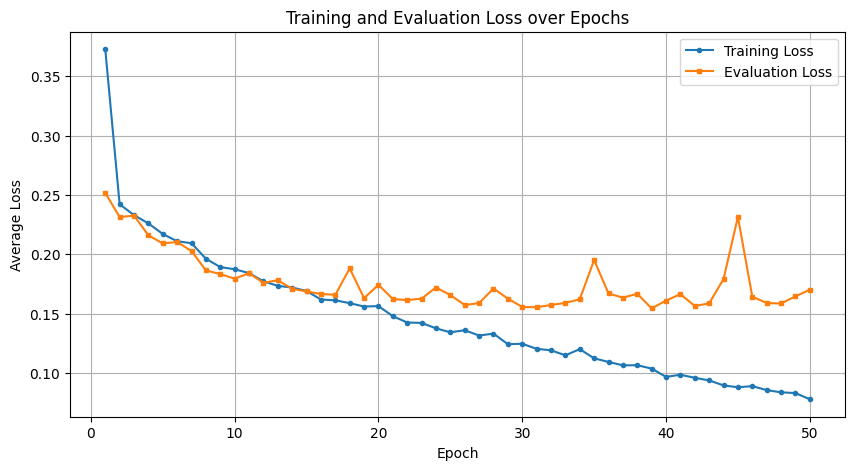

In [45]:
import torch
from torch.utils.data import DataLoader, TensorDataset

# loss function - Binary Cross-Entropy for binary classification
criterion = nn.BCELoss()

# optimizer - Adam optimizer with learning rate 0.001
optimizer = torch.optim.Adam(net.parameters(), lr=0.0001)

# Create tensors from the pandas DataFrames
# Normalize pixel values to [0, 1] range for better training
X_train_tensor = torch.tensor(X_train_frog_ship.values, dtype=torch.float32) / 255.0
y_train_tensor = torch.tensor(y_train_frog_ship.values, dtype=torch.float32)

# Create test tensors
X_test_tensor = torch.tensor(X_test_frog_ship.values, dtype=torch.float32) / 255.0
y_test_tensor = torch.tensor(y_test_frog_ship.values, dtype=torch.float32)

# Create TensorDataset and DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Create test DataLoader for evaluation
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# run training with evaluation
net = train(net, train_loader, criterion, optimizer, 50, eval_dataloader=test_loader)

In [46]:
# # Free memory after training

# import torch
# import gc

# # Delete model and optimizer
# del net
# del optimizer
# del criterion

# # Delete data tensors
# del X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor
# del train_dataset, test_dataset, train_loader, test_loader

# # Clear CUDA cache
# torch.cuda.empty_cache()

# # Run garbage collection
# gc.collect()

# print("GPU memory freed!")

### Task 1.3. Write a code for model evaluation


After we train our neural network, we'll need to evaluate it on test data and compute accuracy metric. Let's now define the function for it. Your task is to fill the gaps in the code below


In [47]:
def evaluate(model, loader, criterion):
    '''
    args:
        model - our neural network model
        loader — structure which yields batches of test data
        criterion - loss function from `torch.nn` module
    '''

    # arrays for storing loss values, network predictions and true values
    losses = []
    y_pred_list = []
    y_true_list = []

    model.eval()  # Set model to evaluation mode
    
    for X_batch, y_batch in loader:
        # Move data to device
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # this disables gradient computations to save time and memory
        # we don't need gradients on test data
        with torch.no_grad():
            # getting our model's predictions on current batch
            y_pred = model(X_batch)

            # calculate loss function
            loss = criterion(y_pred.squeeze(), y_batch)
            losses.append(loss.item())


        # convert outputs of your network into class number
        y_pred = (y_pred >= 0.5).squeeze().cpu().tolist()

        # save for accuracy calculation
        y_pred_list.extend(y_pred if isinstance(y_pred, list) else [y_pred])
        y_true_list.extend(y_batch.cpu().tolist())

    # calculate accuracy score based on y_pred_list and y_true_list
    accuracy = sum(1 for p, t in zip(y_pred_list, y_true_list) if p == t) / len(y_true_list)

    return np.mean(losses), accuracy

And let's evaluate our trained network on test data. Use `test_data_frog_ship` for testing.


In [48]:
test_loader = test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

evaluate(net, test_loader, criterion)

(np.float64(0.17019197705667466), 0.939)

### Task 1.4. Train the neural network to classify frog/ship images

Now you have a network that can be trained and evaluated on binary classification data. Your task is to improve it so that your neural network can achieve **>0.94 accuracy** on the test part.

You are free to build any neural network architecture you want and use any hyperparameters for training. Here are some tips:
- Start with 1-3 hidden layers having, for example, 64-256 neurons each
- Think about how many neurons your input and output layers should have
- What activation function do you need to use in the last layer?
- Play with number of layers, number of neurons, and different activation functions
- Try different training **hyperparameters**: learning rate, number of epochs, optimizer type, batch size

After you've done experimenting, describe your findings. Try to answer the following questions:
- How large should the neural network be to solve the task successfully? There are two dimensions to neural network size: **depth** (number of layers) and **width** (number of neurons in a layer).
- How does the behaviour of the model change when you change different hyperparameters?
- What interesting behaviour have you observed? What was beneficial and what did not influence the model?
- How does the number of epochs needed to achieve the same loss value change when you change the activation function? Fix the network architecture and all training hyperparameters and train the neural network with three different activation functions in hidden layers (Sigmoid, Tanh, ReLU). Plot how training loss evolves during training in these three cases.

Training samples: 8000, Validation samples: 2000, Test samples: 2000
EXPERIMENT: Comparing Activation Functions (ReLU / Tanh / Sigmoid)
Optimizer: SGD

--- Training with RELU activation ---
  Epoch 10/100, Train Loss: 0.2364, Val Loss: 0.2160
  Epoch 20/100, Train Loss: 0.1975, Val Loss: 0.1893
  Epoch 30/100, Train Loss: 0.1740, Val Loss: 0.1809
  Epoch 40/100, Train Loss: 0.1594, Val Loss: 0.1820
  Epoch 50/100, Train Loss: 0.1464, Val Loss: 0.1720
  Epoch 60/100, Train Loss: 0.1403, Val Loss: 0.1618
  Epoch 70/100, Train Loss: 0.1262, Val Loss: 0.1575
  Epoch 80/100, Train Loss: 0.1202, Val Loss: 0.1542
  Epoch 90/100, Train Loss: 0.1117, Val Loss: 0.1569
  Epoch 100/100, Train Loss: 0.1082, Val Loss: 0.1500


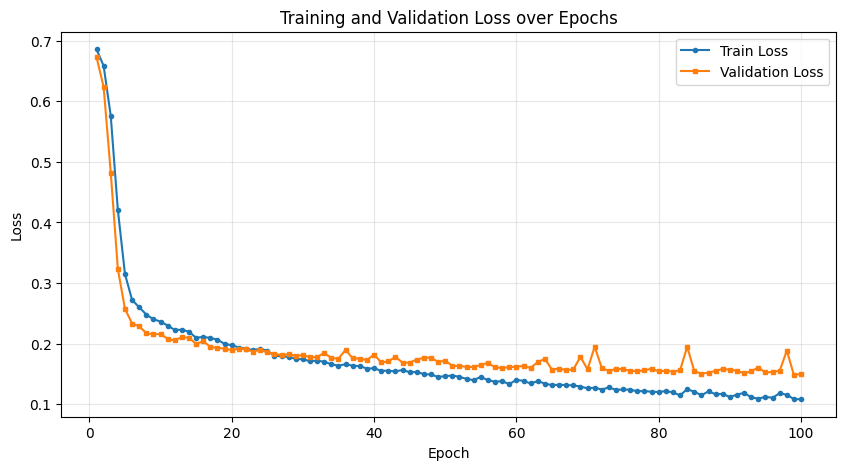

  Val Accuracy: 94.80%
  Test Accuracy: 94.45%

--- Training with TANH activation ---
  Epoch 10/100, Train Loss: 0.2267, Val Loss: 0.2116
  Epoch 20/100, Train Loss: 0.2096, Val Loss: 0.2053
  Epoch 30/100, Train Loss: 0.2014, Val Loss: 0.2126
  Epoch 40/100, Train Loss: 0.1896, Val Loss: 0.1967
  Epoch 50/100, Train Loss: 0.1844, Val Loss: 0.2137
  Epoch 60/100, Train Loss: 0.1814, Val Loss: 0.1902
  Epoch 70/100, Train Loss: 0.1785, Val Loss: 0.1887
  Epoch 80/100, Train Loss: 0.1747, Val Loss: 0.1987
  Epoch 90/100, Train Loss: 0.1698, Val Loss: 0.1869
  Epoch 100/100, Train Loss: 0.1699, Val Loss: 0.1861


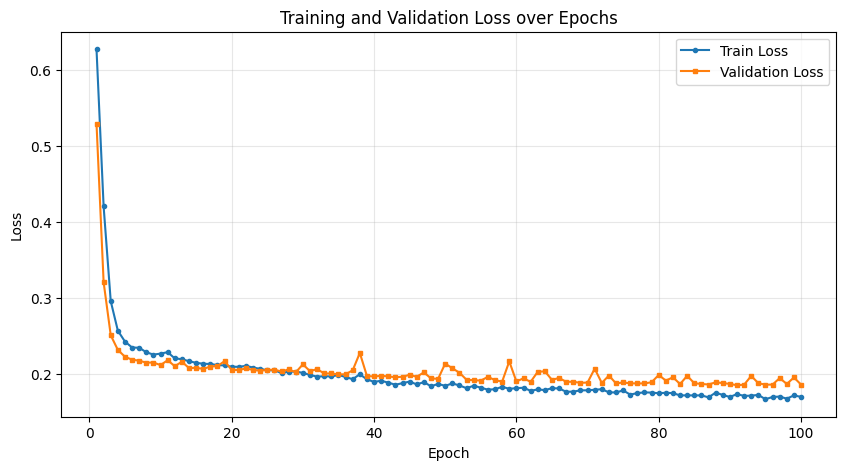

  Val Accuracy: 93.10%
  Test Accuracy: 93.85%

--- Training with SIGMOID activation ---
  Epoch 10/100, Train Loss: 0.6941, Val Loss: 0.6932
  Epoch 20/100, Train Loss: 0.6948, Val Loss: 0.6937
  Early stopping at epoch 24 (no improvement for 15 epochs)


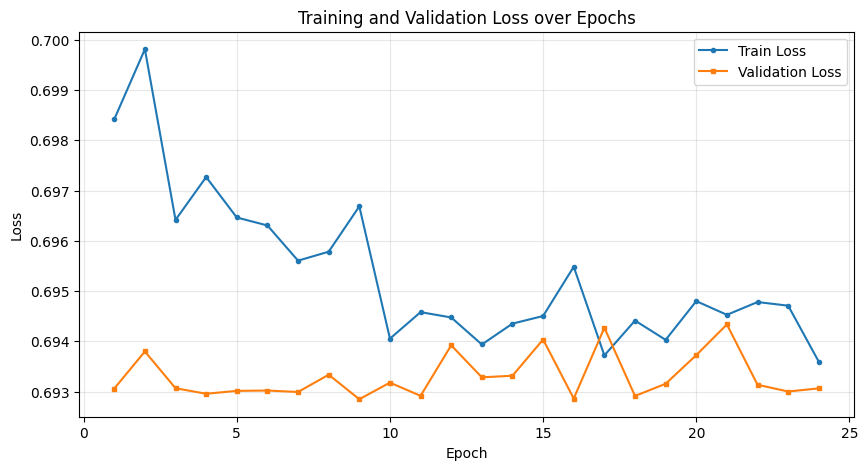

  Val Accuracy: 50.00%
  Test Accuracy: 50.00%


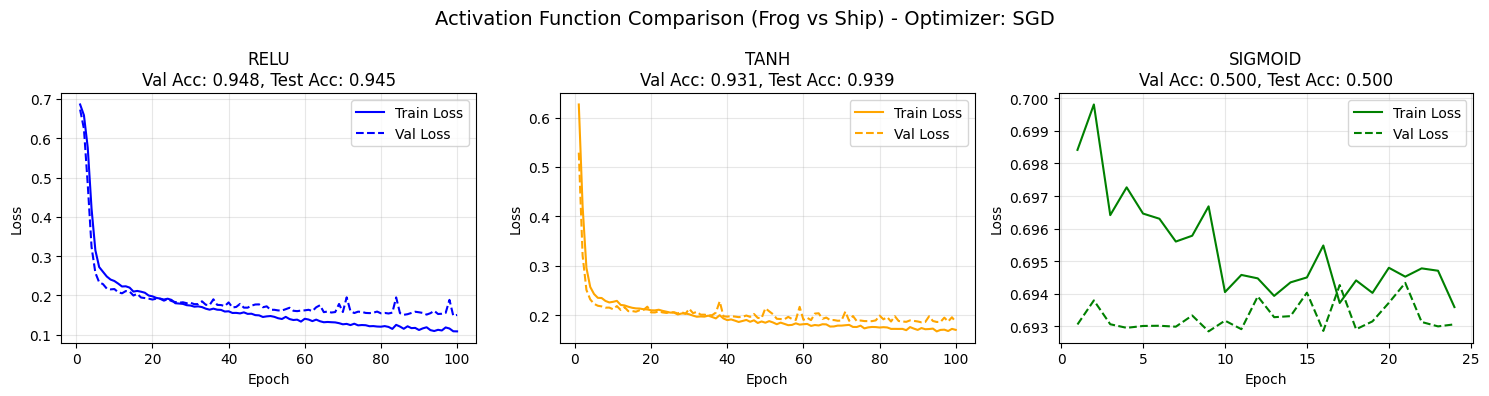

C:\Users\karke\AppData\Local\Temp\ipykernel_3500\2040376400.py:339: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels([act.upper() for act in activation_functions], rotation=45)
C:\Users\karke\AppData\Local\Temp\ipykernel_3500\2040376400.py:348: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels([act.upper() for act in activation_functions], rotation=45)


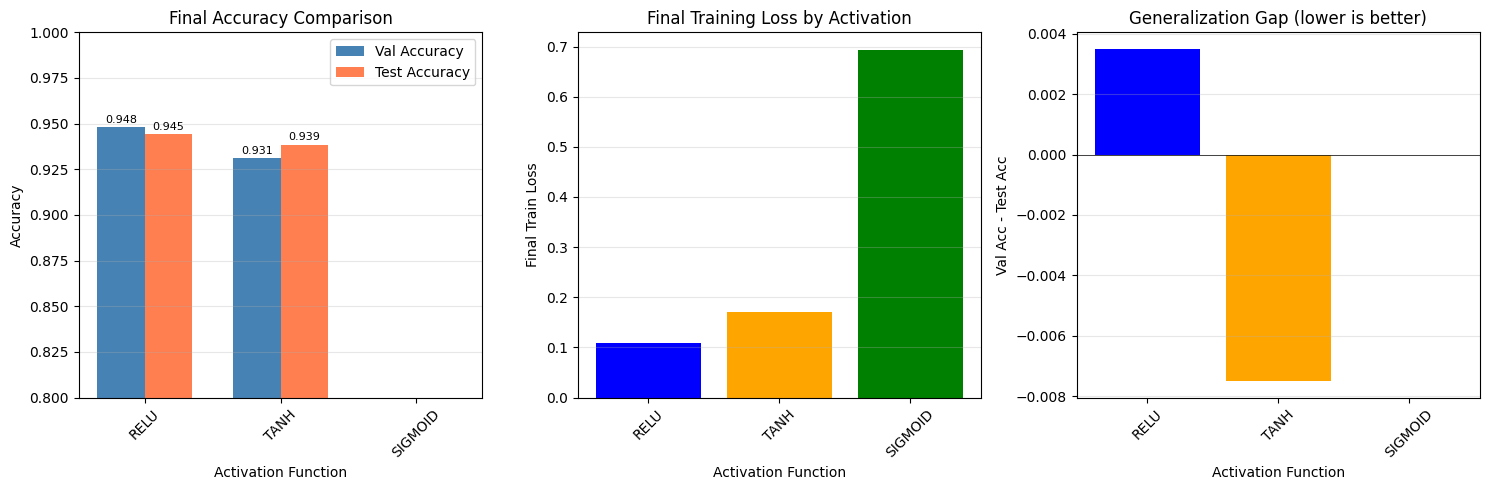


SUMMARY: Best Activation Function for Frog/Ship Classification
Best activation function: RELU
Test accuracy: 0.9445


In [49]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

# =====================
# HYPERPARAMETERS (easy to modify)
# =====================
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
NUM_EPOCHS = 100
WEIGHT_DECAY = 1e-2
VAL_FRACTION = 0.2  # fraction of train_data_frog_ship used as validation
DROPOUT_RATE = 0.3  # dropout probability for regularization

# =====================
# OPTIMIZER CHOICE (uncomment one to experiment)
# =====================
# OPTIMIZER = 'adam'          # Default: Adam optimizer
# OPTIMIZER = 'adamw'       # AdamW: Adam with decoupled weight decay
OPTIMIZER = 'sgd'         # SGD: Stochastic Gradient Descent with momentum
# OPTIMIZER = 'rmsprop'     # RMSprop: Root Mean Square Propagation
# OPTIMIZER = 'nadam'       # NAdam: Adam with Nesterov momentum

# SGD-specific hyperparameters (only used if OPTIMIZER='sgd')
SGD_MOMENTUM = 0.9

def create_optimizer(model, optimizer_name, lr, weight_decay):
    """Create optimizer based on OPTIMIZER choice."""
    if optimizer_name == 'adam':
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == 'adamw':
        return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == 'sgd':
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=SGD_MOMENTUM, weight_decay=weight_decay)
    elif optimizer_name == 'rmsprop':
        return torch.optim.RMSprop(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == 'nadam':
        return torch.optim.NAdam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")

# =====================
# STEP 1: Prepare frog/ship data with explicit train/val split
# =====================
# Reuse frog and ship data extracted earlier
# Split features and labels
X_frog_ship = train_data_frog_ship.drop(columns=['label'])
y_frog_ship = train_data_frog_ship['label']

# Create an explicit validation split from the training data
X_train_frog_ship_split, X_val_frog_ship, y_train_frog_ship_split, y_val_frog_ship = train_test_split(
    X_frog_ship, y_frog_ship, test_size=VAL_FRACTION, random_state=42, stratify=y_frog_ship
)

# Test set (kept only for final evaluation)
X_test_fs = test_data_frog_ship.drop(columns=['label'])
y_test_fs = test_data_frog_ship['label']

# Create tensors (normalized to 0-1 range)
X_train_fs = torch.tensor(X_train_frog_ship_split.values, dtype=torch.float32) / 255.0
y_train_fs = torch.tensor(y_train_frog_ship_split.values, dtype=torch.float32)

X_val_fs = torch.tensor(X_val_frog_ship.values, dtype=torch.float32) / 255.0
y_val_fs = torch.tensor(y_val_frog_ship.values, dtype=torch.float32)

X_test_fs_t = torch.tensor(X_test_fs.values, dtype=torch.float32) / 255.0
y_test_fs_t = torch.tensor(y_test_fs.values, dtype=torch.float32)

# Create data loaders
train_dataset_fs = TensorDataset(X_train_fs, y_train_fs)
val_dataset_fs = TensorDataset(X_val_fs, y_val_fs)
test_dataset_fs = TensorDataset(X_test_fs_t, y_test_fs_t)

train_loader_fs = DataLoader(train_dataset_fs, batch_size=BATCH_SIZE, shuffle=True)
val_loader_fs = DataLoader(val_dataset_fs, batch_size=BATCH_SIZE, shuffle=False)
test_loader_fs = DataLoader(test_dataset_fs, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training samples: {len(X_train_fs)}, Validation samples: {len(X_val_fs)}, Test samples: {len(X_test_fs_t)}")

# =====================
# STEP 2: Define Optimized Neural Network Architecture (LESS WIDE to reduce overfitting)
# =====================
class OptimizedNet(nn.Module):
    """
    Optimized architecture for frog/ship classification:
    - 3 hidden layers with UNIFORM width (256 neurons each)
    - Dropout for regularization
    - Configurable activation function for experiments
    - No BatchNorm (removed to simplify train/eval behavior)
    
    Changed from: 3072 → 512 → 256 → 128 → 1 (~1.7M params)
    To:           3072 → 256 → 256 → 256 → 1  (~820K params)
    """
    def __init__(self, activation_fn='relu'):
        super(OptimizedNet, self).__init__()
        
        # Input: 3072 features (32x32x3 flattened)
        # 3 hidden layers with 256 neurons each
        self.fc1 = nn.Linear(3072, 1052)
        self.fc2 = nn.Linear(1052, 512)
        self.fc3 = nn.Linear(512, 128)
        self.fc4 = nn.Linear(128, 1)
        
        self.dropout = nn.Dropout(DROPOUT_RATE)
        
        # Set activation function
        if activation_fn == 'relu':
            self.activation = nn.ReLU()
        elif activation_fn == 'tanh':
            self.activation = nn.Tanh()
        elif activation_fn == 'sigmoid':
            self.activation = nn.Sigmoid()
        else:
            raise ValueError(f"Unknown activation function: {activation_fn}")
    
    def forward(self, x):
        x = self.dropout(self.activation(self.fc1(x)))
        # x = self.activation(self.fc1(x))
        x = self.dropout(self.activation(self.fc2(x)))
        # x = self.activation(self.fc2(x))
        x = self.dropout(self.activation(self.fc3(x)))
        x = torch.sigmoid(self.fc4(x))
        return x


# =====================
# STEP 3: Training Function with Validation Tracking
# =====================
def train_with_tracking(model, train_loader, val_loader, criterion, optimizer, num_epochs, patience=10):
    """
    Train model with validation tracking and early stopping.

    Args:
        model: PyTorch model
        train_loader, val_loader: DataLoaders
        criterion: Loss function
        optimizer: Optimizer
        num_epochs: Max epochs
        patience: Early stopping patience

    Returns:
        (train_losses, val_losses) per epoch
    """
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None
    
    for epoch in range(num_epochs):
        # ----- Training phase -----
        model.train()
        running_loss = 0.0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        
        epoch_train_loss = running_loss / len(train_loader)
        train_losses.append(epoch_train_loss)
        
        # ----- Validation phase -----
        model.eval()
        val_loss = 0.0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)
                val_loss += loss.item()
        
        epoch_val_loss = val_loss / len(val_loader)
        val_losses.append(epoch_val_loss)
        
        # ----- Early stopping check -----
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1
        
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch + 1}/{num_epochs}, Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}")
        
        # Early stopping
        if patience_counter >= patience:
            print(f"  Early stopping at epoch {epoch + 1} (no improvement for {patience} epochs)")
            # Restore best model
            if best_model_state is not None:
                model.load_state_dict(best_model_state)
            break
    
    # Plot training and validation loss
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss', marker='o', markersize=3)
    plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss', marker='s', markersize=3)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss over Epochs')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()    
    return train_losses, val_losses


# =====================
# STEP 4: Evaluation Functions
# =====================
def evaluate_accuracy(model, loader):
    """Return accuracy (0-1 float) on the given DataLoader."""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            predictions = (outputs > 0.5).float()
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
    return correct / total


# =====================
# STEP 5: Compare Activation Functions (ReLU vs Tanh vs Sigmoid)
# =====================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

activation_functions = ['relu', 'tanh', 'sigmoid']
activation_results = {}

print("=" * 60)
print("EXPERIMENT: Comparing Activation Functions (ReLU / Tanh / Sigmoid)")
print(f"Optimizer: {OPTIMIZER.upper()}")
print("=" * 60)

for act_fn in activation_functions:
    print(f"\n--- Training with {act_fn.upper()} activation ---")
    
    # Create model with specific activation
    net_optimized = OptimizedNet(activation_fn=act_fn).to(device)
    
    criterion = nn.BCELoss()
    optimizer_compare = create_optimizer(
        net_optimized,
        OPTIMIZER,
        LEARNING_RATE,
        WEIGHT_DECAY
    )
    
    # Train with tracking and early stopping
    train_losses, val_losses = train_with_tracking(
        net_optimized, train_loader_fs, val_loader_fs, criterion, optimizer_compare, NUM_EPOCHS, patience=15
    )
    
    # Evaluate on validation and test sets
    val_acc_act = evaluate_accuracy(net_optimized, val_loader_fs)
    test_acc_act = evaluate_accuracy(net_optimized, test_loader_fs)
    
    activation_results[act_fn] = {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_accuracy': val_acc_act,
        'test_accuracy': test_acc_act,
    }
    
    print(f"  Val Accuracy: {val_acc_act * 100:.2f}%")
    print(f"  Test Accuracy: {test_acc_act * 100:.2f}%")

# =====================
# STEP 6: Visualization
# =====================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

colors = {'relu': 'blue', 'tanh': 'orange', 'sigmoid': 'green'}

for idx, act_fn in enumerate(activation_functions):
    ax = axes[idx]
    results = activation_results[act_fn]
    epochs = range(1, len(results['train_losses']) + 1)
    
    ax.plot(epochs, results['train_losses'], label='Train Loss', color=colors[act_fn], linestyle='-')
    ax.plot(epochs, results['val_losses'], label='Val Loss', color=colors[act_fn], linestyle='--')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f'{act_fn.upper()}\nVal Acc: {results["val_accuracy"]:.3f}, Test Acc: {results["test_accuracy"]:.3f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Activation Function Comparison (Frog vs Ship) - Optimizer: {OPTIMIZER.upper()}', fontsize=14)
plt.tight_layout()
plt.show()

# Summary bar chart
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Final validation accuracy comparison
val_accs = [activation_results[act]['val_accuracy'] for act in activation_functions]
test_accs = [activation_results[act]['test_accuracy'] for act in activation_functions]

x = np.arange(len(activation_functions))
width = 0.35

bars_val = ax1.bar(x - width/2, val_accs, width, label='Val Accuracy', color='steelblue')
bars_test = ax1.bar(x + width/2, test_accs, width, label='Test Accuracy', color='coral')
ax1.set_xlabel('Activation Function')
ax1.set_ylabel('Accuracy')
ax1.set_title('Final Accuracy Comparison')
ax1.set_xticks(x)
ax1.set_xticklabels([act.upper() for act in activation_functions], rotation=45)
ax1.legend()
ax1.set_ylim(0.8, 1.0)
ax1.grid(True, alpha=0.3, axis='y')

for bar in bars_val:
    ax1.annotate(f'{bar.get_height():.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                 xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)
for bar in bars_test:
    ax1.annotate(f'{bar.get_height():.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                 xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)

# Final train loss comparison
final_train_losses = [activation_results[act]['train_losses'][-1] for act in activation_functions]
ax2.bar(activation_functions, final_train_losses, color=[colors[act] for act in activation_functions])
ax2.set_xlabel('Activation Function')
ax2.set_ylabel('Final Train Loss')
ax2.set_title('Final Training Loss by Activation')
ax2.set_xticklabels([act.upper() for act in activation_functions], rotation=45)
ax2.grid(True, alpha=0.3, axis='y')

# Generalization gap (val acc - test acc)
gen_gaps = [activation_results[act]['val_accuracy'] - activation_results[act]['test_accuracy'] for act in activation_functions]
ax3.bar(activation_functions, gen_gaps, color=[colors[act] for act in activation_functions])
ax3.set_xlabel('Activation Function')
ax3.set_ylabel('Val Acc - Test Acc')
ax3.set_title('Generalization Gap (lower is better)')
ax3.set_xticklabels([act.upper() for act in activation_functions], rotation=45)
ax3.grid(True, alpha=0.3, axis='y')
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("SUMMARY: Best Activation Function for Frog/Ship Classification")
print("="*60)
best_act = max(activation_results.keys(), key=lambda x: activation_results[x]['test_accuracy'])
print(f"Best activation function: {best_act.upper()}")
print(f"Test accuracy: {activation_results[best_act]['test_accuracy']:.4f}")

#### Exercise 1.4 — Findings

**How large should the network be?**
A 3-hidden-layer network (3072→1052→512→128→1, ~1.6M params) with ReLU and dropout (0.3)  exceeds 94% test accuracy. Depth of 3 hidden layers is sufficient; going to 1–2 layers made it harder to cross the 94% threshold. Width matters more than depth here — having layers with 256 neurons or less underperformed. Adding extra layers didn't add any significant improvement to the model accuracy.

**How does behaviour change with different hyperparameters?**
- **Learning rate:** Too high (>0.01 with SGD) caused unstable training; too low (<1e-4) slowed convergence significantly.
- **Optimizer:** Adam/AdamW converged faster but SGD with momentum (0.9) + weight decay (1e-2) achieved comparable final accuracy with smoother loss curves.
- **Batch size:** Smaller batches (32–64) gave slightly better generalization than large batches (256+).
- **Dropout:** 0.3 dropout helped close the train/val loss gap without hurting final accuracy.
- **Weight decay:** 1e-2 acted as effective regularization alongside dropout.

**What was interesting / beneficial / not influential?**
- Sigmoid activation in hidden layers completely failed — the network got stuck at ~0.693 loss (random guessing, 50% accuracy) and never learned, due to vanishing gradients in the deep network.
- ReLU and Tanh both succeeded, but ReLU converged to a lower final loss (~0.11 vs ~0.18) and slightly higher accuracy (94.4% vs 93.8%).
- Early stopping (patience=15) triggered for Sigmoid at ~27 epochs but was never needed for ReLU/Tanh, which kept improving through all 100 epochs.
- The generalization gap was negligible for all working models (<0.5%), indicating dropout + weight decay regularized well.

**Activation function comparison (fixed architecture, SGD optimizer, 100 epochs):**
| Activation | Epochs to converge | Final Train Loss | Val Acc | Test Acc |
|---|---|---|---|---|
| **ReLU** | ~100 (still improving) | ~0.11 | 94.6% | 94.4% |
| **Tanh** | ~100 (still improving) | ~0.18 | 93.3% | 93.8% |
| **Sigmoid** | Early stopped at ~27 | ~0.693 | 50.0% | 50.0% |

ReLU reaches any given loss level in fewer epochs than Tanh (e.g., loss 0.20 is reached by epoch ~25 for ReLU vs ~35 for Tanh). Sigmoid never reaches meaningful loss reduction at all — it is trapped by vanishing gradients in this 3-layer architecture.

### Task 1.5. Train the neural network to classify cat/dog images


Now that you have optimized your network for frog/ship classification, try to solve cat/dog classification. This task is harder, because cats and dogs can have similar colors, shapes, and poses. Again, your neural network should achieve **>0.64 accuracy** on the test part.

First, try training the same network that you've optimized for the frog/ship task. Can it successfully solve cat/dog classification? If not, experiment with model architecture and hyperparameters again.

In this task you might also need to use BatchNorm and Dropout layers. Here's documentations:
- BatchNorm: https://docs.pytorch.org/docs/stable/generated/torch.nn.BatchNorm1d.html
- Dropout: https://docs.pytorch.org/docs/stable/generated/torch.nn.Dropout.html

**Note:** Both BatchNorm and Dropout layers behave differently on training and inference. Don't forget to set `model.train()` and `model.eval()` before training/evaluation phases.

Below there's also theory block on BatchNorm.

After you've done experimenting, describe your findings. Again, try to answer the following questions:
- How large should the neural network be to solve the task successfully? Is that different from what you had on the frog/ship task?
- How does the behaviour of the model change when you change different hyperparameters?
- What interesting behaviour have you observed? What was beneficial and what did not influence the model?
- How does the number of epochs needed to achieve the same loss value change when you change the activation function? Fix the network architecture and all training hyperparameters and train the neural network with three different activation functions in hidden layers (Sigmoid, Tanh, ReLU). Plot how training loss evolves during training in these three cases.

Here is also an example of visual appearance of these classes — you may want to inspect several training images manually to understand why the task is difficult.

Cat/Dog — Train: 8000, Val: 2000, Test: 2000
Training Cat/Dog classifier — Activation: LEAKY_RELU, Optimizer: SGD
  Epoch 10/400, Train Loss: 0.6931, Val Loss: 0.6925
  Epoch 20/400, Train Loss: 0.6920, Val Loss: 0.6912
  Epoch 30/400, Train Loss: 0.6903, Val Loss: 0.6888
  Epoch 40/400, Train Loss: 0.6852, Val Loss: 0.6847
  Epoch 50/400, Train Loss: 0.6807, Val Loss: 0.6810
  Epoch 60/400, Train Loss: 0.6756, Val Loss: 0.6771
  Epoch 70/400, Train Loss: 0.6693, Val Loss: 0.6730
  Epoch 80/400, Train Loss: 0.6651, Val Loss: 0.6707
  Epoch 90/400, Train Loss: 0.6612, Val Loss: 0.6644
  Epoch 100/400, Train Loss: 0.6556, Val Loss: 0.6614
  Epoch 110/400, Train Loss: 0.6527, Val Loss: 0.6577
  Epoch 120/400, Train Loss: 0.6452, Val Loss: 0.6536
  Epoch 130/400, Train Loss: 0.6449, Val Loss: 0.6521
  Epoch 140/400, Train Loss: 0.6385, Val Loss: 0.6572
  Epoch 150/400, Train Loss: 0.6316, Val Loss: 0.6473
  Epoch 160/400, Train Loss: 0.6256, Val Loss: 0.6481
  Epoch 170/400, Train Loss: 0.

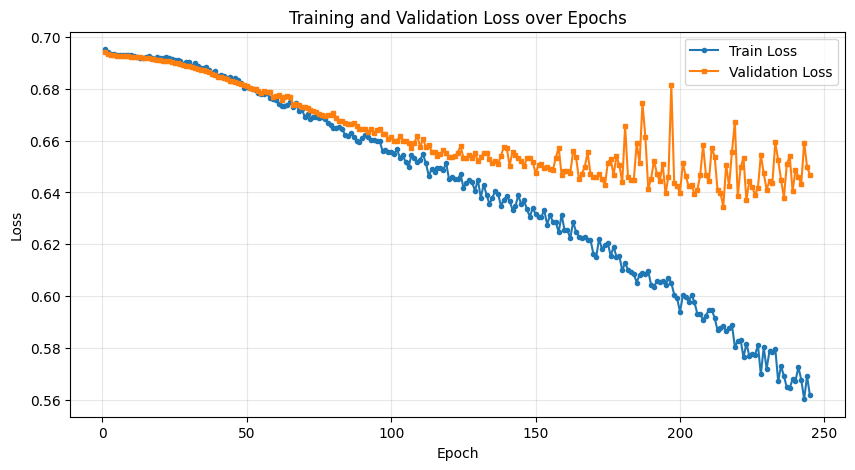


RESULTS: Cat/Dog Classification
  Activation:    LEAKY_RELU
  Optimizer:     SGD
  Train Acc:     77.61%
  Val Acc:       63.55%
  Test Acc:      64.70%
  Target:        > 64.00%
  PASSED


In [67]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

# =====================
# HYPERPARAMETERS — Cat/Dog (modify these to experiment)
# =====================
CD_BATCH_SIZE = 64
CD_LEARNING_RATE = 1e-3
CD_NUM_EPOCHS = 400
CD_WEIGHT_DECAY = 1e-3
CD_VAL_FRACTION = 0.2
CD_DROPOUT_RATE = 0.6
CD_PATIENCE = 30          # early stopping patience

# Activation function for hidden layers ('relu', 'tanh', 'sigmoid', 'leaky_relu')
CD_ACTIVATION = 'leaky_relu'
CD_LEAKY_RELU_SLOPE = 0.01  # only used if CD_ACTIVATION='leaky_relu'

# Optimizer choice (uncomment one to experiment)
CD_OPTIMIZER = 'sgd'
# CD_OPTIMIZER = 'adam'
# CD_OPTIMIZER = 'adamw'
# CD_OPTIMIZER = 'rmsprop'
# CD_OPTIMIZER = 'nadam'

# SGD-specific (only used if CD_OPTIMIZER='sgd')
CD_SGD_MOMENTUM = 0.9

# =====================
# STEP 1: Prepare cat/dog data with train/val split
# =====================
X_train_cd = train_data_cat_dog.drop(columns=['label'])
y_train_cd = train_data_cat_dog['label']

X_train_cd, X_val_cd, y_train_cd, y_val_cd = train_test_split(
    X_train_cd, y_train_cd, test_size=CD_VAL_FRACTION, random_state=42, stratify=y_train_cd
)

X_test_cat_dog_features = test_data_cat_dog.drop(columns=['label'])
y_test_cat_dog_labels = test_data_cat_dog['label']

# Create tensors (normalized to 0-1)
X_train_cd_t = torch.tensor(X_train_cd.values, dtype=torch.float32) / 255.0
y_train_cd_t = torch.tensor(y_train_cd.values, dtype=torch.float32)

X_val_cd_t = torch.tensor(X_val_cd.values, dtype=torch.float32) / 255.0
y_val_cd_t = torch.tensor(y_val_cd.values, dtype=torch.float32)

X_test_cd_t = torch.tensor(X_test_cat_dog_features.values, dtype=torch.float32) / 255.0
y_test_cd_t = torch.tensor(y_test_cat_dog_labels.values, dtype=torch.float32)

# DataLoaders
train_dataset_cd = TensorDataset(X_train_cd_t, y_train_cd_t)
val_dataset_cd = TensorDataset(X_val_cd_t, y_val_cd_t)
test_dataset_cd = TensorDataset(X_test_cd_t, y_test_cd_t)

train_loader_cd = DataLoader(train_dataset_cd, batch_size=CD_BATCH_SIZE, shuffle=True)
val_loader_cd = DataLoader(val_dataset_cd, batch_size=CD_BATCH_SIZE, shuffle=False)
test_loader_cd = DataLoader(test_dataset_cd, batch_size=CD_BATCH_SIZE, shuffle=False)

print(f"Cat/Dog — Train: {len(X_train_cd_t)}, Val: {len(X_val_cd_t)}, Test: {len(X_test_cd_t)}")


# =====================
# STEP 2: Define CatDogNet (same architecture as task 1.4, with BatchNorm commented out)
# =====================
class CatDogNet(nn.Module):
    """
    Architecture: 3072 → 1052 → 512 → 128 → 1
    Same as OptimizedNet from task 1.4.
    BatchNorm lines are commented out — uncomment to experiment with BatchNorm.
    When BatchNorm is enabled, order is: Linear → BatchNorm → Activation → Dropout.
    """
    def __init__(self, activation_fn=CD_ACTIVATION):
        super(CatDogNet, self).__init__()

        self.fc1 = nn.Linear(3072, 1052)
        self.bn1 = nn.BatchNorm1d(1052)   # <-- uncomment for BatchNorm
        self.fc2 = nn.Linear(1052, 512)
        self.bn2 = nn.BatchNorm1d(512)    # <-- uncomment for BatchNorm
        self.fc3 = nn.Linear(512, 128)
        self.bn3 = nn.BatchNorm1d(128)    # <-- uncomment for BatchNorm
        self.fc4 = nn.Linear(128, 32)
        self.bn4 = nn.BatchNorm1d(32)    # <-- uncomment for BatchNorm        
        self.fc5 = nn.Linear(32, 1)

        self.dropout = nn.Dropout(CD_DROPOUT_RATE)

        # Activation function
        if activation_fn == 'relu':
            self.activation = nn.ReLU()
        elif activation_fn == 'leaky_relu':
            self.activation = nn.LeakyReLU(negative_slope=CD_LEAKY_RELU_SLOPE)
        elif activation_fn == 'tanh':
            self.activation = nn.Tanh()
        elif activation_fn == 'sigmoid':
            self.activation = nn.Sigmoid()
        else:
            raise ValueError(f"Unknown activation function: {activation_fn}")

    def forward(self, x):
        # Layer 1: Linear → (BatchNorm) → Activation → Dropout
        x = self.fc1(x)
        # x = self.bn1(x)                  # <-- uncomment for BatchNorm
        x = self.dropout(self.activation(x))

        # Layer 2: Linear → (BatchNorm) → Activation → Dropout
        x = self.fc2(x)
        # x = self.bn2(x)                  # <-- uncomment for BatchNorm
        x = self.dropout(self.activation(x))

        # Layer 3: Linear → (BatchNorm) → Activation → Dropout
        x = self.fc3(x)
        # x = self.bn3(x)                  # <-- uncomment for BatchNorm
        x = self.dropout(self.activation(x))

        # Layer 4: Linear → (BatchNorm) → Activation → Dropout
        x = self.fc4(x)
        # x = self.bn4(x)                  # <-- uncomment for BatchNorm
        x = self.dropout(self.activation(x))

        # Output layer
        x = torch.sigmoid(self.fc5(x))
        return x


# =====================
# STEP 3: Create optimizer helper (uses CD_ hyperparameters)
# =====================
def create_cd_optimizer(model, optimizer_name, lr, weight_decay):
    """Create optimizer based on CD_OPTIMIZER choice."""
    if optimizer_name == 'adam':
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == 'adamw':
        return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == 'sgd':
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=CD_SGD_MOMENTUM, weight_decay=weight_decay)
    elif optimizer_name == 'rmsprop':
        return torch.optim.RMSprop(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == 'nadam':
        return torch.optim.NAdam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")


# =====================
# STEP 4: Train
# =====================
print("=" * 60)
print(f"Training Cat/Dog classifier — Activation: {CD_ACTIVATION.upper()}, Optimizer: {CD_OPTIMIZER.upper()}")
print("=" * 60)

net_cd = CatDogNet(activation_fn=CD_ACTIVATION).to(device)
criterion_cd = nn.BCELoss()
optimizer_cd = create_cd_optimizer(net_cd, CD_OPTIMIZER, CD_LEARNING_RATE, CD_WEIGHT_DECAY)

train_losses_cd, val_losses_cd = train_with_tracking(
    net_cd, train_loader_cd, val_loader_cd, criterion_cd, optimizer_cd,
    CD_NUM_EPOCHS, patience=CD_PATIENCE
)


# =====================
# STEP 5: Evaluate
# =====================
train_acc_cd = evaluate_accuracy(net_cd, train_loader_cd)
val_acc_cd = evaluate_accuracy(net_cd, val_loader_cd)
test_acc_cd = evaluate_accuracy(net_cd, test_loader_cd)

print("\n" + "=" * 60)
print("RESULTS: Cat/Dog Classification")
print("=" * 60)
print(f"  Activation:    {CD_ACTIVATION.upper()}")
print(f"  Optimizer:     {CD_OPTIMIZER.upper()}")
print(f"  Train Acc:     {train_acc_cd * 100:.2f}%")
print(f"  Val Acc:       {val_acc_cd * 100:.2f}%")
print(f"  Test Acc:      {test_acc_cd * 100:.2f}%")
print(f"  Target:        > 64.00%")
print(f"  {'PASSED' if test_acc_cd > 0.64 else 'NOT YET — keep experimenting!'}")
print("=" * 60)

#### Exercise 1.5 — Findings

**Network size 
- Depper network used (4 hi=idden layers)

**Hyperparameter behaviour**
- **Optimizer:** SGD (lr=1e-3, momentum=0.9); Other optimisers failed to achieve the target score (again!). I assume this is caused by the local minima on the "surface" of the loss function for this example.
- **Dropout:** Lowered to 0.6 for strong regularisation
- **Weight decay:** Reduced to 1e-3 (from 1e-2)
- The evaluation scoring is not stable at the end of the training, so the model may have passed by chance. 
- Batch normalisation killed the learning. I couldn' make it work, even tried to remove dropout layer.
- It was generally a pain!!!




Great! Now that we've tried to solve binary classification on CIFAR-10 data, we'll switch to the task of **multi-class classification**. But before that, let's talk about the `Dataset` class in PyTorch.


#### BatchNorm

Now let us talk about a new type of network layer: batch normalization. This is a layer that helps make training more stable and faster. In addition, a neural network with batch normalization layers can often learn a task better than the same network without batch normalization.

Let us consider a neural network with several layers. Notice that layers 2–3 of this network can be viewed as a separate, smaller neural network. The input data for this smaller network are the outputs of the first layer.

We already know that, for better neural network training, the input data should be normalized. Therefore, normalizing the outputs of each intermediate layer also helps the network train better. BatchNorm is exactly the layer that performs this kind of normalization.

There is also a second reason to normalize the outputs of intermediate layers. This is the internal covariate shift effect in neural networks. Originally, BatchNorm was introduced as a way to eliminate this effect.

network.svg

What is internal covariate shift? Consider a neural network with several layers. During training, all layers are trained jointly. Each layer of the network must adapt to the values produced by the previous layer. However, during training, the distribution of values produced by each layer changes. As a result, at every iteration of the algorithm, each hidden layer has to adapt to a new distribution of outputs from the previous layer. This makes the network train more slowly. Moreover, the weights can change quite significantly at each training iteration, which may provoke other problems, such as exploding gradients.

Normalizing the outputs of the network layers would help solve this problem.

So, how can we implement normalization of layer outputs? The simplest idea is to strictly normalize the output of each layer before passing it further through the network, just as we normalize the input data. For example, we could force the mean of all layer outputs to be 0 and the variance to be 1.

But why not give the neural network more freedom and allow it to determine for itself how exactly it is best to normalize the outputs of each layer?

That is precisely the idea behind BatchNorm. BatchNorm is a trainable layer that normalizes network outputs using trainable parameters.


**A BatchNorm layer is applied after a network layer and works as follows:**

1. Compute the mean $\mu_B$ and variance $\sigma_B$ of the layer outputs over the batch. That is, suppose we have b outputs of the layer $\{x_i\}_{i=1}^b$, where $b$ is the batch size. Then:
    
$$\mu_B = \frac{\sum_{i=1}^b x_i}{b}$$

$$\sigma_B^2 = \frac{\sum_{i=1}^b (x_i - \mu_B)^2}{b}$$

2.	Normalize the layer outputs:

$$\widehat{x_i} = \frac{x_i - \mu_B}{\sigma_B}$$

3.	Compute the updated layer outputs as

$$y_i = \gamma \widehat{x_i} + \beta$$

where $\gamma$ and $\beta$ are trainable parameters.

Basically, BatchNorm shifts mean of each neuron's output in the current batch to $\beta$, and variance to $\gamma$.

However, in this setup we will have a problem on inference, when we should be able to compute network's predictions on a single element. If we have only one element in a batch, we can't reliably estimate mean and variance to apply BatchNorm. The idea of a fix here is the following: during inference, we will use statistics for $\mu_B$ and $\sigma^2_B$ that we have computed during training.

For this reason, BatchNorm behaves differently during training and during inference. **During training, BatchNorm will do the following:**

Initialize running mean $\mu_r$ and $\sigma_B$ as zero. Set *momentum* hyperparameter to some constant between 0 and 1.

1. Compute the mean $\mu_B$ and variance $\sigma_B$ of the layer outputs over the batch. That is, suppose we have b outputs of the layer $\{x_i\}_{i=1}^b$, where $b$ is the batch size. Then:
    
$$\mu_B = \frac{\sum_{i=1}^b x_i}{b}$$

$$\sigma_B^2 = \frac{\sum_{i=1}^b (x_i - \mu_B)^2}{b}$$

Update the running mean and running variance:

$$\mu_r = (1-momentum)*\mu_r + momentum*\mu_B$$
$$\sigma_r = (1-momentum)*\sigma_r + momentum*\sigma_B$$

2.	Normalize the layer outputs:

$$\widehat{x_i} = \frac{x_i - \mu_B}{\sigma_B}$$

3.	Compute the updated layer outputs as

$$y_i = \gamma \widehat{x_i} + \beta$$

where $\gamma$ and $\beta$ are trainable parameters.

Then we use $\mu_r$ and $\sigma_r$ during inference instead of batch-based statistics. So, **during inference BatchNorm does the following:**

1. Normalize the layer outputs:

$$\widehat{x_i} = \frac{x_i - \mu_r}{\sigma_r}$$

3.	Compute the updated layer outputs using trained $\gamma$ and $\beta$ as

$$y_i = \gamma \widehat{x_i} + \beta$$



## Task 2. Dataset class


In the task above we worked with CIFAR-10 data that we loaded into NumPy/Pandas structures and then passed directly to dataloaders. In PyTorch there is a class called `Dataset` which allows us to work with data in a more flexible way. It lets us define custom transformations of the data before passing it into the model.

In this task you will need to define a `Dataset` class based on our CIFAR-10 data. We will then use it for training a neural network for multi-class classification of the whole CIFAR-10 dataset.


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

### Task 2.1 Implement `CIFAR10Dataset` class.


Your task is to fill in the blanks in the cell below. Please note the following:
- The `__init__` method usually stores the input data in class variables. In our case the data comes into `__init__` as a pandas DataFrame. To access elements by index faster in the `__getitem__` method, convert the data to `np.array` format inside `__init__`.
- If you want to apply transformations to the data before feeding it to the neural network (normalization, reshaping, etc.), this is usually done in the `__getitem__` method. We would like to normalize our images, i.e. bring all pixel values to the interval `[0, 1]`. To do this, divide all pixel values by `255.`. Note that normalization should be done in the `__getitem__` method, **not** in `__init__`. This is checked by asserts later and by the testing system when the task is submitted.
- Below you will train a neural network to classify CIFAR images into 10 classes using this Dataset class. You might experiment with other transformations to help your network fit better. For example, you might want to resize images before feeding them into the model or convert images into grayscale — this would lower number of image pixels by 3! Pillow library (https://pypi.org/project/pillow/) can help you with that. You will need first to reshape your image vector into 32x32x3, convert to Pilow Image format, resize/do other transformations, concert back to Numpy and flatten the image back into the vector. You can think of other transformations that might help.


**Note**: here we start to use all labels in CIFAR dataset, as below we will build a neural network for multi-class classification (all 10 CIFAR classes). So you don't need to select data elements with certain labels anymore.

In [ ]:
class CIFAR10Dataset(Dataset):
    def __init__(self, data):
        '''
        params:
            data (pd.DataFrame) — dataframe with flattened CIFAR-10 images and column `label`
        '''

        # load the data and
        # split it into features and target variable
        # and convert both to np.array
        # please do not change names of variables self.X and self.y,
        # it is important for the checks below to work correctly

        # features
        self.X = data.drop(columns=['label']).values
        # target variable
        self.y = data['label'].values

    def __len__(self):
        '''
        method that returns the number of objects in a dataset.
        This method is used by dataloader to generate batches of data
        '''
        return len(self.X)

    def __getitem__(self, idx):
        '''
        method that, given an index idx, returns the dataset object
        corresponding to the index.
        This method is used by dataloader to form batches of data
        params:
            idx: index of an element of the data
        '''

        # - get an object of data by index idx;
        # - normalize features (divide each pixel by 255.);
        # - convert features and target to tensor
        features = self.X[idx] / 255.
        target = self.y[idx]
        
        return torch.tensor(features, dtype=torch.float32), torch.tensor(target, dtype=torch.long)

Now we can define training and testing datasets. We'll do this for multi-class classification using the whole CIFAR-10 dataframe.


In [ ]:
cifar_train_dataset = CIFAR10Dataset(train_data)
cifar_test_dataset = CIFAR10Dataset(test_data)


The cell below checks that your Dataset class is implemented correctly


In [ ]:
# check that types of self.X and self.y are np.array
assert type(cifar_train_dataset.X) == np.ndarray, "type of self.X in cifar_train_dataset is not np.array"
assert type(cifar_train_dataset.y) == np.ndarray, "type of self.y in cifar_train_dataset is not np.array"

# check that data is not normalized in __init__ method
assert max(cifar_train_dataset.X[0]) == 255, "data should not be normalized in __init__ method"

# check that data is normalized correctly in __getitem__ method
assert float(torch.max(cifar_train_dataset[0][0])) <= 1.0, "data is not normalized in __getitem__ method or it is normalized incorrectly"
assert float(torch.min(cifar_train_dataset[0][0])) >= 0.0, "data is not normalized in __getitem__ method or it is normalized incorrectly"

# check that __getitem__ returns tensors
assert type(cifar_train_dataset[0][0]) == torch.Tensor, '__getitem__ returns other data type than tensor'
assert type(cifar_train_dataset[0][1]) == torch.Tensor, '__getitem__ returns other data type than tensor'


Great! After this we're ready to use our datasets. Now we can use `cifar_train_dataset` and `cifar_test_dataset` in `DataLoader`:


In [ ]:
train_loader = torch.utils.data.DataLoader(cifar_train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(cifar_test_dataset, batch_size=64, shuffle=False)


Now we will train and test our network for multi-class classification using these new dataloaders.


## Task 3. Multi-class classification with NNs


### Neural network for multi-class classification


We already know how to build a neural network for the tasks of binary classification and regression. Let's learn what to do if we have a task of multi-class classification.



Consider a dataset for classification of crocodiles into 3 types:


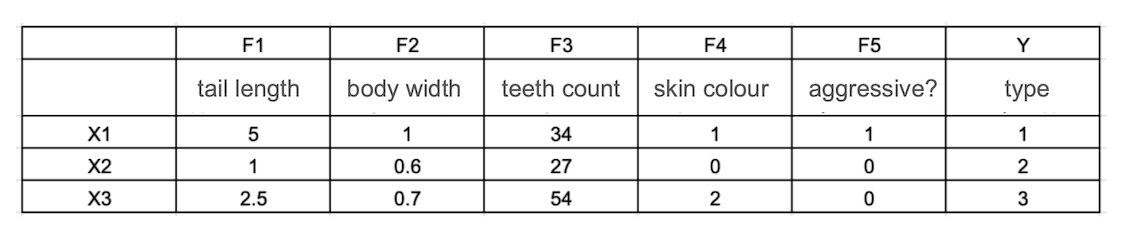


The simplest idea of neural network architecture for this task would be having one output neuron, which would output the class number of input object.


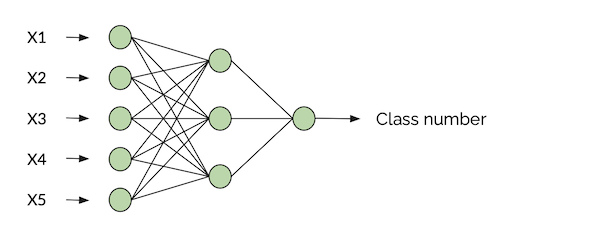


But there's a problem: how do we interpret outputs of such network? Let's say for some object our network outputs the value of 2.12. Does it mean that most likely our object belongs to the class 2? Or does the network think that the object is somewhere in between classes 1 and 3?


Okay, this was not the greatest idea. Let's now note, that a task of milti-class classification to $n$ classes can be wieved as $n$ binary classification tasks:
- does element belong to class 1?
- does element belong to class 2?
- ...
- does element belong to class n?

We can then make our neural network have n output neurons with Sigmoid activation function, and each output neuron will solve a corresponding binary classification tasks. So in our case with crocodile data it will look like that:


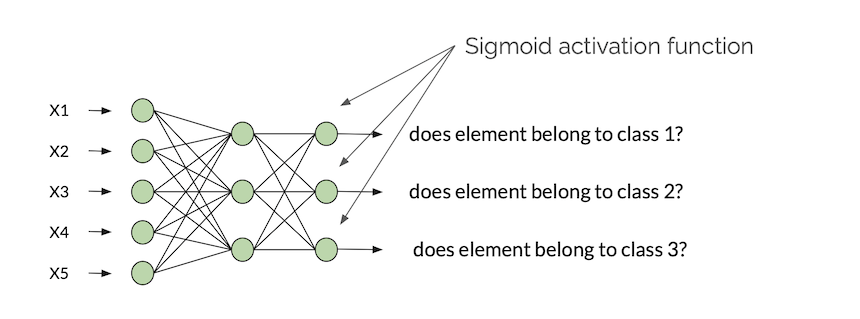


Such a network structure is suitable for the task of multi-label classification, where each input object can belong to arbitrary number of classes, i.e. where events "input object X belongs to class i" are independent. In the case of multi-class classification, these events are not independent, as each object can only belong to one class. So we would like decisions of neuron of the last layer to be agreed in some way.


The idea that comes to mind is the following: we would like neurons of the last layer to output a probability distribution over the classes. This means that the output of $i^{th}$ neuron will represent a probability that the input object belongs to the class $i$.

We also know the true distribution for each object, which is represented as one-hot vector. So as a loss function we could use some similarity measure between the true and predicted distributions.


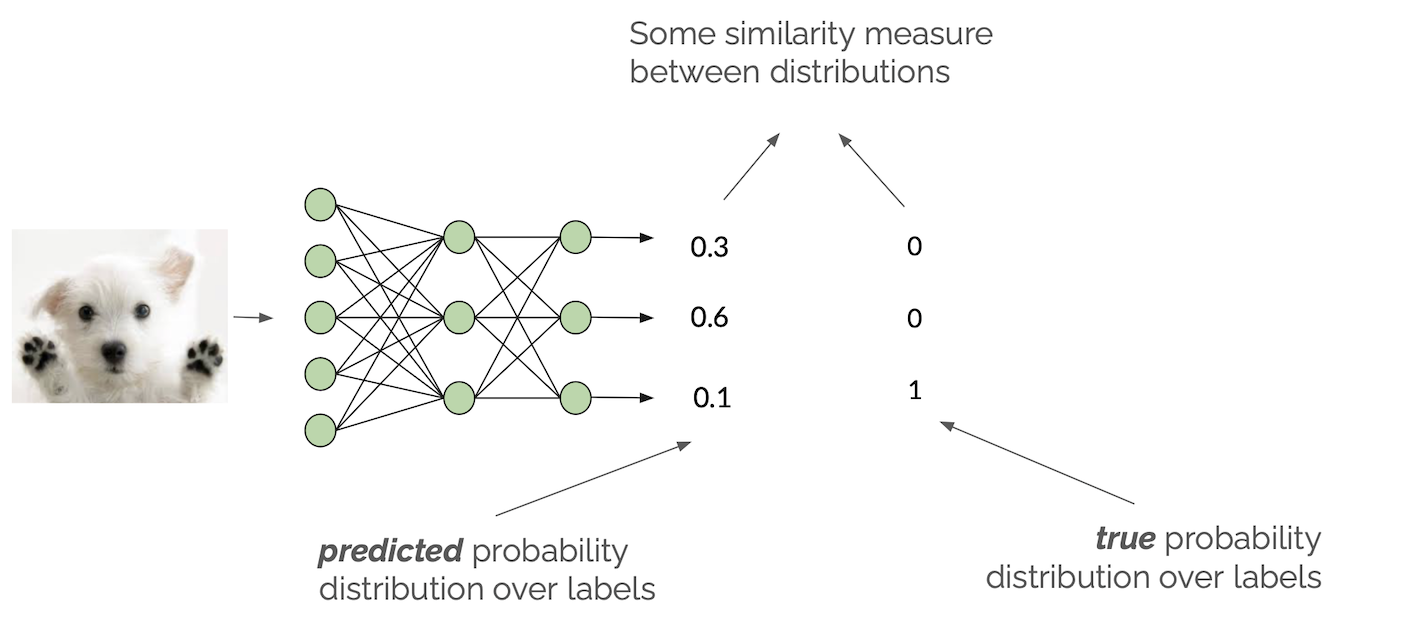


So we need to somehow convert the logits (outputs of the last linear layer) into the probability distribution. Let's do it using SoftMax activation function:

$$(p_1, p_2, p_3) = SoftMax(\widehat{p_1}, \widehat{p_2}, \widehat{p_3}) = \left( \frac{e^{\widehat{p_1}}}{\sum e^{\widehat{p_i}}}, \frac{e^{\widehat{p_2}}}{\sum e^{\widehat{p_i}}}, \frac{e^{\widehat{p_3}}}{\sum e^{\widehat{p_i}}} \right)$$

We can see that SoftMax does indeed convert logits into probability distribution, as the sum of all elements becomes 1, and value of each element is in $[0, 1]$.

And as a similarity measure between the output distribution and true distribution we will use [cross-entropy](https://en.wikipedia.org/wiki/Cross-entropy), which is a measure of similarity of two probability distrubutions from information theory.

$$CE(y, p) = - \sum y_i log(p_i)$$

LogLoss is a binary version of cross-entropy.





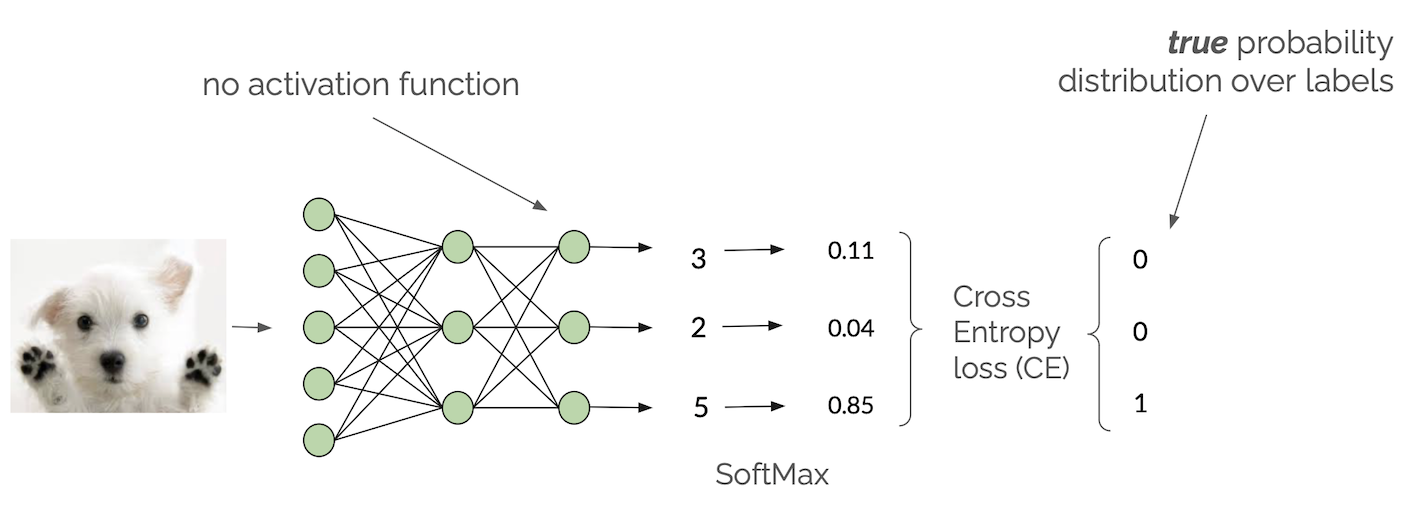


Let's also say a couple of words about why using SoftMax, as there are many ways to convert logits into probability distribution.

First, here's log function inside the formula of cross-entropy. If we pass logits $\widehat{p_i}$ through exponential function before feeding them into cross-entropy, we will end up $log(p_i)$ having the same magnitude as $\widehat{p_i}$. So this will encourage a neural network to output logits which have the same magnitude as $y_i$.

Second, SoftMax is a short for "Soft Maximum", and it has this name because it rebalances the values so that the maximum value becomes more pronounced, close to 1, while all other values get closer to zero.

Here's an example of how SoftMax changes logits:


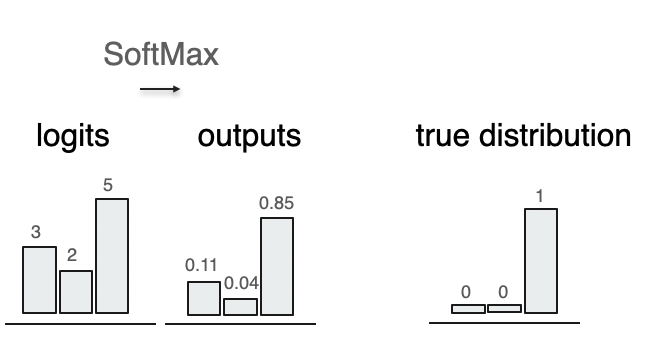


So it is called "Soft Maximum", as it acts almost like argmaximum function, but softer, not putting all the probability weight into one place.


To sum up, if you are building neural network for $n$-class classification task with $n>2$, then:
- last layer of the network should have $n$ neurons
- activation of the last layer of the network should be SoftMax (https://pytorch.org/docs/stable/generated/torch.nn.Softmax.html)
- loss function is cross-entropy (https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)

Note, however, that PyTorch implementation of CE (torch.nn.CrossEntropyLoss) expects to have logits as input, not probabilities after SoftMax. It applies SoftMax inside loss function. This is done due to efficiency of computing gradients. So if you use torch.nn.CrossEntropyLoss as loss function, there should be no activation function in the last layer of the network.


### Task 3.1 Write a neural network for multi-class classification


Define a neural network that should solve a multi-class classification task with 10 classes on CIFAR-10. Think about the following:
- How many input and output neurons should your network have?
- What activation function should the last layer have?


In [ ]:
import torch.nn as nn

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

        # define layers and activation function that your model will have
        # YOUR CODE HERE


    def forward(self, x):

        # define a flow of input through your layers
        # YOUR CODE HERE

        return x


And create a network:


In [ ]:
net = Net()


### Task 3.2 Define a train function


You can copy it from the task above. Does the train function need any modification given that now we're solving a multi-class classification task?


In [ ]:
import tqdm
from tqdm.auto import tqdm

# define a function
# you can change arguments of this function if you want
def train(model, dataloader, criterion, optimizer, num_epoch):
    pass

    # YOUR CODE HERE


And let's define loss function, optimizer, dataloader and train our network. Use the full `cifar_train_dataset` here.


In [ ]:
# loss function
criterion = # YOUR CODE HERE — define a loss function (cross-entropy)
# optimizer
optimizer = # YOUR CODE HERE — define an optimizer and pass params of neural network to it
# dataloader
train_loader = # YOUR CODE HERE — define a train loader

# run training
NN = train(NN, train_loader, criterion, optimizer, 60)


### Task 3.3. Write a code for model evaluation


Again, you can borrow the code from the task above. Does the train function need any modification given that now we're solving a multi-class classification task?


In [ ]:
def evaluate(model, loader, criterion):
    '''
    args:
        model - our neural network model
        loader — structure which yields batches of test data
        criterion - loss function from `torch.nn` module
    '''

    # arrays for storing loss values, network predictions and true values
    losses = []
    y_pred_list = []
    y_true_list = []

    for X_batch, y_batch in loader:

        # this disables gradient computations to save time and memory
        # we don't need gradients on test data
        with torch.no_grad():
            # getting our model's predictions on current batch
            y_pred = # YOUR CODE HERE

            # calculate loss function
            loss = # YOUR CODE HERE
            losses.append(loss.item())


        # convert outputs of your network into class number
        y_pred = # YOUR CODE HERE

        # save for accuracy calculation
        y_pred_list.extend(y_pred)
        y_true_list.extend(y_batch.tolist())

    # calculate accuracy score based on y_pred_list and y_true_list
    accuracy = # YOUR CODE HERE

    return np.mean(losses), accuracy


### Task 3.4 Train the neural network.


Here, again, your task is to improve the network so that it can achieve higher accuracy. Try to achieve **>0.53 accuracy** on the CIFAR-10 test part, but in general your goal is to improve as much as possible.

You are free to build any neural network architecture you want and use any hyperparameters for training. Here are some tips:
- Start with 1-3 hidden layers having, for example, 128-512 neurons each
- Think about how many neurons your input and output layers should have
- What activation function do you need to use in the last layer? **Be careful here:** check the documentation of the loss function that use are using: does it require logits or probabilities?
- Play with number of layers, numbers of neurons, and different activation functions
- Try different training hyperparameters: learning rate, number of epochs, optimizer type, batch size
- As we've discussed above, play with data preprocessing in the Dataset class.

While you're doing experimenting, describe your findings. Try to answer the following questions:
- How large should the neural network be to solve the task successfully? There are two dimensions to neural network size: **depth** and **width**.
- How does the behaviour of the model change when you change different hyperparameters?
- What interesting behaviour have you observed? What was beneficial and what did not influence the model?
- How does the number of epochs needed to achieve the same value of loss function change when you change the activation function? Fix the network architecture and all training hyperparameters and train the neural network with three different activation functions in hidden layers (Sigmoid, Tanh, ReLU). Plot how training loss evolves during training in these three cases.


In [ ]:
# YOUR CODE HERE

That's it for the tasks in this notebook!
